In [1]:
!pip install ultralytics

In [2]:
import os

dataset_path = r"C:\Users\intern\Downloads\archive2\data"

print(os.listdir(dataset_path))
#list the dir

['test', 'train', 'val']


In [3]:
for root, dirs, files in os.walk(dataset_path):
    print(root)
    break
  #treaverse the dir  

C:\Users\intern\Downloads\archive2\data


In [4]:
import os

image_dir = r"C:\Users\intern\Downloads\archive2\data\train\images"
label_dir = r"C:\Users\intern\Downloads\archive2\data\train\labels"

missing_labels = []

for img in os.listdir(image_dir):
    label = img.replace(".jpg", ".txt").replace(".png", ".txt")
    
    if not os.path.exists(os.path.join(label_dir, label)):
        missing_labels.append(img)

print("Images without labels:", len(missing_labels))
#check labelling

Images without labels: 0


In [6]:
fire = 0
smoke = 0

for file in os.listdir(label_dir):
    
    with open(os.path.join(label_dir,file)) as f:
        
        for line in f:
            
            if line.startswith("0"):
                fire += 1
            if line.startswith("1"):
                smoke += 1

print("Fire labels:", fire)
print("Smoke labels:", smoke)
 

Fire labels: 7794
Smoke labels: 9638


In [10]:
import random

label_files = os.listdir(label_dir)

sample = random.choice(label_files)

with open(os.path.join(label_dir, sample)) as f:
    print(f.read())
    #to check the annotation

1 0.36693548387096775 0.47750000000000004 0.5016129032258064 0.03
1 0.6870967741935484 0.47625 0.06451612903225806 0.0275
1 0.8040322580645162 0.48 0.12741935483870967 0.025
1 0.9330645161290323 0.47875 0.10483870967741936 0.0225



In [9]:
import cv2

corrupted_images = []

for img in os.listdir(image_dir):
    
    path = os.path.join(image_dir, img)
    
    image = cv2.imread(path)
    
    if image is None:
        bad_images.append(img)

print("Corrupted images:", len(corrupted_images))#corrupted images

Corrupted images: 0


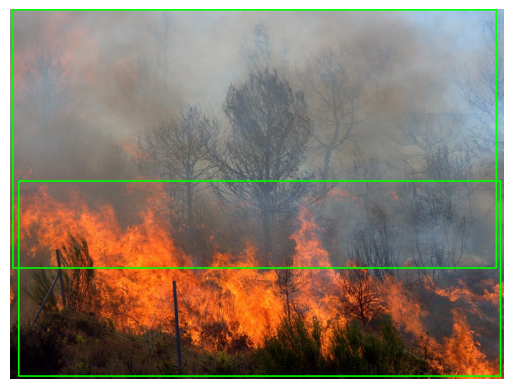

In [2]:
import cv2
import os
import random
import matplotlib.pyplot as plt

image_dir = r"C:\Users\intern\Downloads\archive2\data\train\images"
label_dir = r"C:\Users\intern\Downloads\archive2\data\train\labels"

img_file = random.choice(os.listdir(image_dir)) #random image selection

img_path = os.path.join(image_dir, img_file)
label_path = os.path.join(label_dir, img_file.replace(".jpg",".txt"))#create image and label path

img = cv2.imread(img_path)
h, w, _ = img.shape #read

with open(label_path) as f:#label format(Yolo)
    
    for line in f:
        
        cls, x, y, bw, bh = map(float,line.split())
        
        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)
        
        cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)#bounding box

img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()
#

In [3]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    if "data.yaml" in files:
        print("Found data.yaml at:", os.path.join(root, "data.yaml"))

In [2]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data=r"C:\Users\intern\Downloads\archive2\data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device= "cpu",
    project="fire_smoke_detection",
    name="yolov8_fire_smoke_new"
) #training

New https://pypi.org/project/ultralytics/8.4.24 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.21  Python-3.14.3 torch-2.10.0+cpu CPU (Intel Xeon w7-3465X)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\intern\Downloads\archive2\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001F335EA7A10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0

In [50]:
total_layers = sum(1 for _ in model.model.modules())
print(f"Total number of layers: {total_layers}")

Total number of layers: 169


In [51]:
import torch.nn as nn

activations = set()

for layer in model.model.modules():
    if isinstance(layer, (nn.ReLU, nn.SiLU, nn.Sigmoid, nn.LeakyReLU)):
        activations.add(layer.__class__.__name__)

print("Activation functions used:", activations)

Activation functions used: {'SiLU'}


In [5]:
import os

print(os.getcwd())

C:\Users\intern


In [43]:
os.listdir("runs/detect/fire_smoke_detection/yolov8_fire_smoke_new2/weights")

['best.pt', 'last.pt']

In [10]:
from ultralytics import YOLO

model = YOLO("runs/detect/fire_smoke_detection/yolov8_fire_smoke_new2/weights/best.pt")

In [15]:
%matplotlib inline

Total images found: 3099
Displaying: C:/Users/intern/Downloads/archive2/data/val/images\WEB08817.jpg

image 1/1 C:\Users\intern\Downloads\archive2\data\val\images\WEB08817.jpg: 384x640 1 smoke, 36.3ms
Speed: 2.6ms preprocess, 36.3ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)


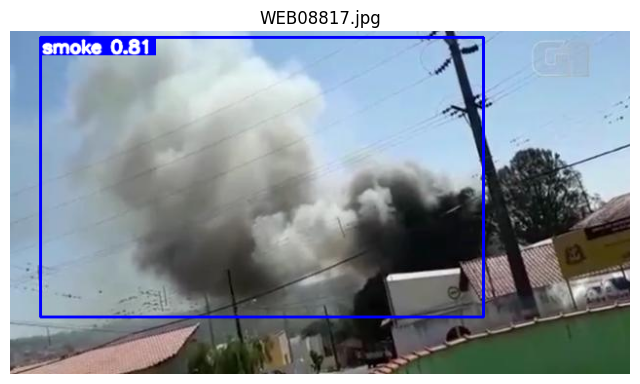

Displaying: C:/Users/intern/Downloads/archive2/data/val/images\WEB06195.jpg

image 1/1 C:\Users\intern\Downloads\archive2\data\val\images\WEB06195.jpg: 480x640 1 smoke, 36.1ms
Speed: 1.8ms preprocess, 36.1ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)


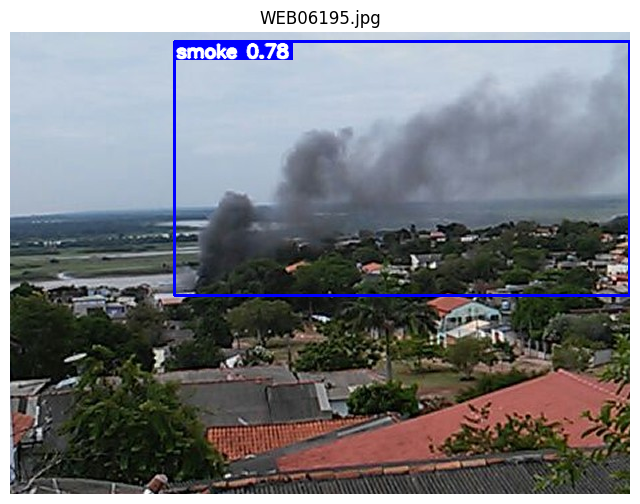

Displaying: C:/Users/intern/Downloads/archive2/data/val/images\AoF01273.jpg

image 1/1 C:\Users\intern\Downloads\archive2\data\val\images\AoF01273.jpg: 384x640 (no detections), 28.7ms
Speed: 1.4ms preprocess, 28.7ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)


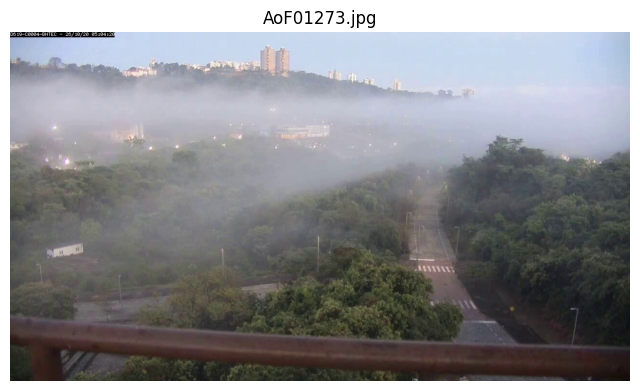

Displaying: C:/Users/intern/Downloads/archive2/data/val/images\WEB03573.jpg

image 1/1 C:\Users\intern\Downloads\archive2\data\val\images\WEB03573.jpg: 480x640 (no detections), 36.6ms
Speed: 2.9ms preprocess, 36.6ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)


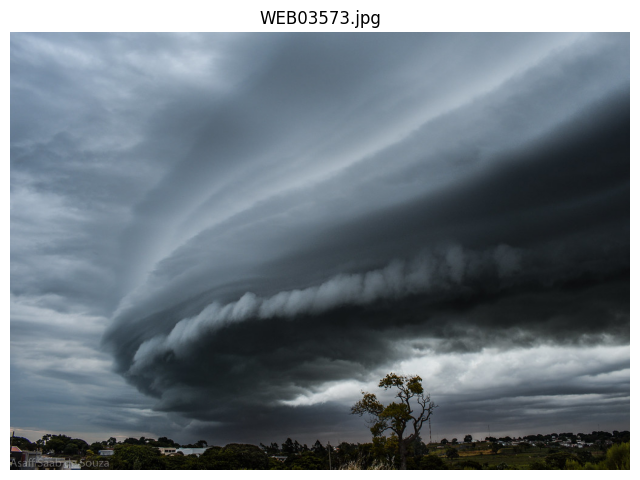

Displaying: C:/Users/intern/Downloads/archive2/data/val/images\WEB06516.jpg

image 1/1 C:\Users\intern\Downloads\archive2\data\val\images\WEB06516.jpg: 512x640 1 smoke, 36.3ms
Speed: 2.7ms preprocess, 36.3ms inference, 0.7ms postprocess per image at shape (1, 3, 512, 640)


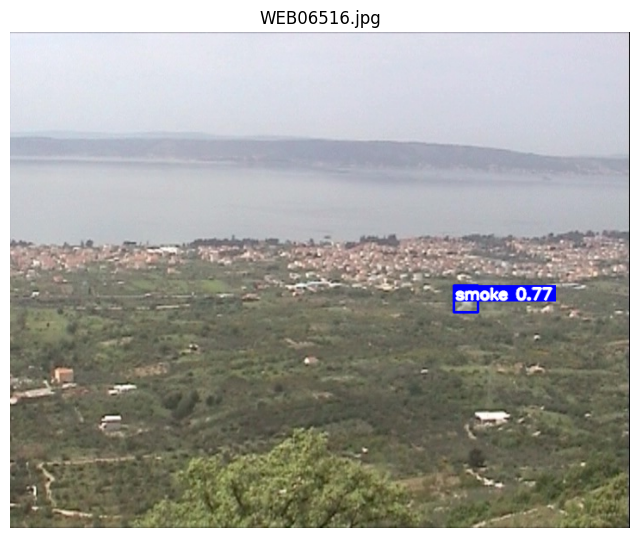

In [34]:
# validation- display images 
import random
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load model
model = YOLO(
"C:/Users/intern/runs/detect/fire_smoke_detection/yolov8_fire_smoke_new2/weights/best.pt"
)

val_path = "C:/Users/intern/Downloads/archive2/data/val/images"

images = [f for f in os.listdir(val_path) if f.lower().endswith((".jpg", ".png", ".jpeg"))]

print(f"Total images found: {len(images)}")

sample_images = random.sample(images, 5)

for img_name in sample_images:
    img_path = os.path.join(val_path, img_name)
    print("Displaying:", img_path)

    results = model(img_path, conf=0.25)

    img = cv2.imread(img_path)

    for box in results[0].boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        label = model.names[cls]
        text = f"{label} {conf:.2f}"

        # Assign colors
        if label == "fire":
            color = (0, 0, 255)   # red
        elif label == "smoke":
            color = (255, 0, 0)   # blue
        else:
            color = (0, 255, 0)
        
        # Draw bounding box
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

        # Get text size
        text = f"{label} {conf:.2f}"

        (w, h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)

        # Draw filled rectangle inside box (top-left corner)
        cv2.rectangle(img, (x1, y1), (x1 + w + 4, y1 + h + 4), color, -1)

        # Put text on top of filled rectangle
        cv2.putText(
            img,
            text,
            (x1 + 2, y1 + h + 2),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 255, 255),   # white text for contrast
            2,
            cv2.LINE_AA
        )

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
"C:/Users/intern/runs/detect/fire_smoke_detection/yolov8_fire_smoke_new2/weights/best.pt"
    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.title(img_name)
    plt.axis("off")
    plt.show()

In [58]:
#validation-metrices
import pandas as pd

model = YOLO(
"C:/Users/intern/runs/detect/fire_smoke_detection/yolov8_fire_smoke_new2/weights/best.pt"
)

metrics = model.val(
    data="C:/Users/intern/Downloads/archive2/data.yaml",
    split="val",
    imgsz=640
)

rows = []

for i, name in model.names.items():
    precision = float(metrics.box.p[i])
    recall = float(metrics.box.r[i])
    map50 = float(metrics.box.ap50[i])
    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    rows.append({
        "Class": name,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "mAP@0.5": map50
    })

# Add overall averages
rows.append({
    "Class": "Overall",
    "Precision": float(metrics.box.mp),
    "Recall": float(metrics.box.mr),
    "F1-Score": 2 * metrics.box.mp * metrics.box.mr / (metrics.box.mp + metrics.box.mr + 1e-6),
    "mAP@0.5": float(metrics.box.map50)
})

df = pd.DataFrame(rows)
print(df)
accuracy = float(metrics.box.map50) * 100
print(f"Model Accuracy: {accuracy:.2f}%")

Ultralytics 8.4.21  Python-3.14.3 torch-2.10.0+cpu CPU (Intel Xeon w7-3465X)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 264.641.5 MB/s, size: 69.9 KB)
val: Scanning C:\Users\intern\Downloads\archive2\data\val\labels.cache... 3099 images, 1375 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3099/3099 590.8Mit/s 0.0s
val: C:\Users\intern\Downloads\archive2\data\val\images\WEB07535.jpg: corrupt JPEG restored and saved
val: C:\Users\intern\Downloads\archive2\data\val\images\WEB07536.jpg: corrupt JPEG restored and saved
val: C:\Users\intern\Downloads\archive2\data\val\images\WEB07539.jpg: corrupt JPEG restored and saved
val: C:\Users\intern\Downloads\archive2\data\val\images\WEB07542.jpg: corrupt JPEG restored and saved
val: C:\Users\intern\Downloads\archive2\data\val\images\WEB07561.jpg: corrupt JPEG restored and saved
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%